In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.pyplot import figure
import plot_helper as helper

# Input data

In [2]:
group_cols = ["layer", "concept", "mode"]
metric_cols = ["retention", "purity", "leakage", "interference"]


in_path = "../output/raw_score-v2_clean.csv"
df = pd.read_csv(in_path)
# df = df.sort_values(by=["method", "concept"], key=helper.sort_key)
df = df[df["layer"] == 11]
df["method"] = df["method"].replace("LC", "MLR")
df["method"] = df["method"].replace("PCA", "CPCA")

# average random experiments
random_avg = (
    df[df["method"].str.contains("RANDOM", na=False)]
    .assign(method="RAND")
    .groupby(group_cols + ["method"], as_index=False)[metric_cols]
    .mean()
)

df = pd.concat(
    [
        df[~df["method"].str.contains("RANDOM", na=False)],
        random_avg,
    ],
    ignore_index=True,
).drop(columns=["layer"])
df[metric_cols] = df[metric_cols] * 100

In [3]:
model2markers = helper.model2markers
model2color = helper.model2color

BOUNDARY_COLOR = "C7"
# BOUNDARY_LINESTYLES_WORST = "dashed"
# BOUNDARY_LINESTYLES_BEST = "dotted"
BOUNDARY_LINESTYLES = "dashed"
BOUNDARY_ALPHA = 0.9
BOUNDARY_LINE_WIDTH=1
FIG_SIZE=(2,2)
FIG_DPI=100
FONT_SIZE_BIG=11
FONT_SIZE_DEFAULT=9
MARKER_SIZE=100
MARKER_ALPHA = 0.7
BOUNDARY_ALPHA = 0.7

ARROW_COLOR = "black"
ARROW_TEXT = "better"

matplotlib.rcParams.update({'font.size': FONT_SIZE_DEFAULT})
PLOTTING_ESTIMATORS = ['BEST', 'RAND', 'MLR', 'LDA', 'CPCA', 'COV', 'LEACE'] #'
PLOTTING_ESTIMATORS

['BEST', 'RAND', 'MLR', 'LDA', 'CPCA', 'COV', 'LEACE']

# Phone plots

In [4]:
output_dir = "plots/main_exp_reproduce"
os.makedirs(output_dir, exist_ok=True)
target_concept = "phone"

sel_df = df[df["concept"] == target_concept]
reten_score = sel_df["retention"].to_numpy()
leak_score = sel_df["leakage"].to_numpy()
pur_score = sel_df["purity"].to_numpy()
int_score = sel_df["interference"].to_numpy()
labels = sel_df[sel_df["concept"] == target_concept]["method"].to_numpy()

In [5]:
sel_df

,concept,method,mode,seed,retention,purity,leakage,interference
0,phone,WORST,clean,0.0,7.889915,20.032219,87.802359,97.287227
1,phone,BEST,clean,0.0,87.802359,97.287227,7.889915,20.032219
2,phone,EYE,clean,0.0,87.802359,20.032219,7.889915,97.287227
3,phone,MLR,clean,0.0,87.078461,93.080748,85.761015,22.624889
4,phone,LDA,clean,0.0,82.717036,94.610526,86.163135,21.971905
5,phone,CPCA,clean,0.0,76.699992,94.671192,29.900351,21.155368
6,phone,COV,clean,0.0,76.646704,94.762602,29.933964,21.106588
7,phone,LEACE,clean,0.0,82.719086,94.547400,29.910189,21.145940
16,phone,RAND,clean,NaN,57.227380,92.688138,87.652660,22.509787


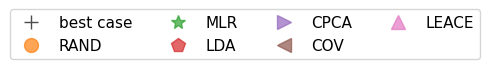

saved: plots/main_exp_reproduce/legend.png


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def formatting_name(name):
    return name.replace("BEST", "best case")


def plot_legend(labels, output_dir):    
    labels_marker = [x_.split(" ")[0] for x_ in labels]
    f = lambda m,c: plt.plot([],[],marker=m, color=c, ls="none", markersize=MARKER_SIZE**0.5, alpha=MARKER_ALPHA)[0]
    fig_legend = plt.figure(figsize=(3, 0.5))
    handles = [f(model2markers[labels_marker[i]], model2color[labels_marker[i]]) for i in range(len(labels_marker))]
    labels_marker = [formatting_name(lab) for lab in labels_marker]
    legend = fig_legend.legend(handles, labels_marker, loc='center', ncol=4, frameon=True, fontsize=FONT_SIZE_BIG)
    fig_legend.gca().set_axis_off()
    fig_legend.tight_layout()
    fig_legend.savefig(os.path.join(output_dir, f"legend.png"), dpi=FIG_DPI, bbox_inches="tight")
    plt.show()
    print("saved:", os.path.join(output_dir, f"legend.png"))

# [2:] skips WORST and BEST rows
plot_legend(labels=PLOTTING_ESTIMATORS, output_dir=output_dir)

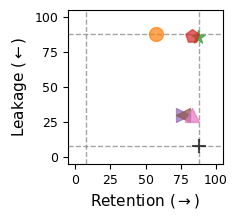

saved: plots/main_exp_reproduce/phone_containment.png


In [7]:
#containment
fig, ax = plt.subplots(1, 1, figsize=FIG_SIZE, dpi=FIG_DPI, sharey=True)

# BEST
ax.hlines(reten_score[0], -5, 105, color=BOUNDARY_COLOR, alpha=BOUNDARY_ALPHA, zorder=-5, linestyles=BOUNDARY_LINESTYLES, linewidth=BOUNDARY_LINE_WIDTH)
ax.vlines(leak_score[0], -5, 105, color=BOUNDARY_COLOR, alpha=BOUNDARY_ALPHA, zorder=-5, linestyles=BOUNDARY_LINESTYLES, linewidth=BOUNDARY_LINE_WIDTH)
# WORST
ax.hlines(reten_score[1], -5, 105, color=BOUNDARY_COLOR, alpha=BOUNDARY_ALPHA, zorder=-5, linestyles=BOUNDARY_LINESTYLES, linewidth=BOUNDARY_LINE_WIDTH)
ax.vlines(leak_score[1], -5, 105, color=BOUNDARY_COLOR, alpha=BOUNDARY_ALPHA, zorder=-5, linestyles=BOUNDARY_LINESTYLES, linewidth=BOUNDARY_LINE_WIDTH)


for i in range(len(reten_score)):    
    if labels[i] in PLOTTING_ESTIMATORS:        
        ax.scatter(reten_score[i], leak_score[i], marker=model2markers[labels[i]], label=labels[i], s=MARKER_SIZE, alpha=MARKER_ALPHA, color=model2color[labels[i]]) 

# plot arrow
# ax.annotate("", xytext=(10,40), xy=(40,10),
#             arrowprops=dict(
#                     arrowstyle="simple",
#                     color=ARROW_COLOR,
#                 ))
# ax.text(17, 17, ARROW_TEXT, rotation=-45, color=ARROW_COLOR, fontsize=FONT_SIZE_DEFAULT)

ax.set_xlim([-5, 105])
ax.set_ylim([-5, 105])
ax.set_xticks(np.arange(0,101,25), np.arange(0,101,25))
ax.set_yticks(np.arange(0,101,25), np.arange(0,101,25))
ax.set_xlabel(r"Retention $(\rightarrow)$", fontsize=FONT_SIZE_BIG)
ax.set_ylabel(r"Leakage $(\leftarrow)$", fontsize=FONT_SIZE_BIG)
# plt.title(f"{target_concept} containment", fontsize=FONT_SIZE_BIG)
plt.savefig(os.path.join(output_dir, f"{target_concept}_containment.png"), dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print("saved:", os.path.join(output_dir, f"{target_concept}_containment.png"))

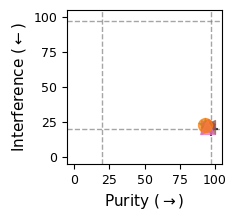

saved: plots/main_exp_reproduce/phone_disentanglement.png


In [8]:
#disentanglement
fig, ax = plt.subplots(1, 1, figsize=FIG_SIZE, dpi=FIG_DPI, sharey=True)

# BEST
ax.hlines(pur_score[0], -5, 105, color=BOUNDARY_COLOR, alpha=BOUNDARY_ALPHA, zorder=-5, linestyles=BOUNDARY_LINESTYLES, linewidth=BOUNDARY_LINE_WIDTH)
ax.vlines(int_score[0], -5, 105, color=BOUNDARY_COLOR, alpha=BOUNDARY_ALPHA, zorder=-5, linestyles=BOUNDARY_LINESTYLES, linewidth=BOUNDARY_LINE_WIDTH)
# WORST
ax.hlines(pur_score[1], -5, 105, color=BOUNDARY_COLOR, alpha=BOUNDARY_ALPHA, zorder=-5, linestyles=BOUNDARY_LINESTYLES, linewidth=BOUNDARY_LINE_WIDTH)
ax.vlines(int_score[1], -5, 105, color=BOUNDARY_COLOR, alpha=BOUNDARY_ALPHA, zorder=-5, linestyles=BOUNDARY_LINESTYLES, linewidth=BOUNDARY_LINE_WIDTH)


for i in range(len(reten_score)):
    if labels[i] in PLOTTING_ESTIMATORS:       
        ax.scatter(pur_score[i], int_score[i], marker=model2markers[labels[i]], label=labels[i], s=MARKER_SIZE, alpha=MARKER_ALPHA, color=model2color[labels[i]])

# plot arrow
# ax.annotate("", xytext=(10,40), xy=(40,10),
#             arrowprops=dict(
#                     arrowstyle="simple",
#                     color=ARROW_COLOR,
#                 ))
# ax.text(17, 17, ARROW_TEXT, rotation=-45, color=ARROW_COLOR, fontsize=FONT_SIZE_DEFAULT)

ax.set_xlim([-5, 105])
ax.set_ylim([-5, 105])
ax.set_xticks(np.arange(0,101,25), np.arange(0,101,25))
ax.set_yticks(np.arange(0,101,25), np.arange(0,101,25))
ax.set_xlabel(r"Purity $(\rightarrow)$", fontsize=FONT_SIZE_BIG)
ax.set_ylabel(r"Interference $(\leftarrow)$", fontsize=FONT_SIZE_BIG)
# plt.title("{target_concept} disentanglement", fontsize=FONT_SIZE_BIG)
plt.savefig(os.path.join(output_dir, f"{target_concept}_disentanglement.png"), dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print("saved:", os.path.join(output_dir, f"{target_concept}_disentanglement.png"))

# Speaker plots

In [9]:
target_concept = "spk"

sel_df = df[df["concept"] == target_concept]
reten_score = sel_df["retention"].to_numpy()
leak_score = sel_df["leakage"].to_numpy()
pur_score = sel_df["purity"].to_numpy()
int_score = sel_df["interference"].to_numpy()
labels = sel_df[sel_df["concept"] == target_concept]["method"].to_numpy()

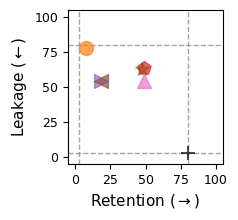

saved: plots/main_exp_reproduce/spk_containment.png


In [10]:
fig, ax = plt.subplots(1, 1, figsize=FIG_SIZE, dpi=FIG_DPI, sharey=True)
# BEST
ax.hlines(reten_score[0], -5, 105, color=BOUNDARY_COLOR, alpha=BOUNDARY_ALPHA, zorder=-5, linestyles=BOUNDARY_LINESTYLES, linewidth=BOUNDARY_LINE_WIDTH)
ax.vlines(leak_score[0], -5, 105, color=BOUNDARY_COLOR, alpha=BOUNDARY_ALPHA, zorder=-5, linestyles=BOUNDARY_LINESTYLES, linewidth=BOUNDARY_LINE_WIDTH)
# WORST
ax.hlines(reten_score[1], -5, 105, color=BOUNDARY_COLOR, alpha=BOUNDARY_ALPHA, zorder=-5, linestyles=BOUNDARY_LINESTYLES, linewidth=BOUNDARY_LINE_WIDTH)
ax.vlines(leak_score[1], -5, 105, color=BOUNDARY_COLOR, alpha=BOUNDARY_ALPHA, zorder=-5, linestyles=BOUNDARY_LINESTYLES, linewidth=BOUNDARY_LINE_WIDTH)



for i in range(len(reten_score)):
    if labels[i] in PLOTTING_ESTIMATORS:
        ax.scatter(reten_score[i], leak_score[i], marker=model2markers[labels[i]], label=labels[i], s=MARKER_SIZE, alpha=MARKER_ALPHA, color=model2color[labels[i]])

# plot arrow
# ax.annotate("", xytext=(5,32), xy=(32,5),
#             arrowprops=dict(
#                     arrowstyle="simple",
#                     color=ARROW_COLOR,
#                 ))
# ax.text(8, 14, ARROW_TEXT, rotation=-45, color=ARROW_COLOR, fontsize=FONT_SIZE_DEFAULT)

ax.set_xlim([-5, 105])
ax.set_ylim([-5, 105])
ax.set_xticks(np.arange(0,101,25), np.arange(0,101,25))
ax.set_yticks(np.arange(0,101,25), np.arange(0,101,25))
ax.set_xlabel(r"Retention $(\rightarrow)$", fontsize=FONT_SIZE_BIG)
ax.set_ylabel(r"Leakage $(\leftarrow)$", fontsize=FONT_SIZE_BIG)
# plt.title("Speaker containment", fontsize=FONT_SIZE_BIG)
plt.savefig(os.path.join(output_dir, f"{target_concept}_containment.png"), dpi=FIG_DPI,  bbox_inches="tight")
plt.show()
print("saved:", os.path.join(output_dir, f"{target_concept}_containment.png"))

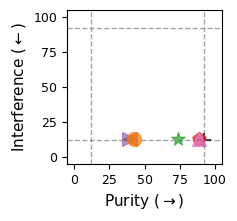

saved: plots/main_exp_reproduce/spk_disentanglement.png


In [11]:
fig, ax = plt.subplots(1, 1, figsize=FIG_SIZE, dpi=FIG_DPI, sharey=True)

# BEST
ax.hlines(pur_score[0], -5, 105, color=BOUNDARY_COLOR, alpha=BOUNDARY_ALPHA, zorder=-5, linestyles=BOUNDARY_LINESTYLES, linewidth=BOUNDARY_LINE_WIDTH)
ax.vlines(int_score[0], -5, 105, color=BOUNDARY_COLOR, alpha=BOUNDARY_ALPHA, zorder=-5, linestyles=BOUNDARY_LINESTYLES, linewidth=BOUNDARY_LINE_WIDTH)
# WORST
ax.hlines(pur_score[1], -5, 105, color=BOUNDARY_COLOR, alpha=BOUNDARY_ALPHA, zorder=-5, linestyles=BOUNDARY_LINESTYLES, linewidth=BOUNDARY_LINE_WIDTH)
ax.vlines(int_score[1], -5, 105, color=BOUNDARY_COLOR, alpha=BOUNDARY_ALPHA, zorder=-5, linestyles=BOUNDARY_LINESTYLES, linewidth=BOUNDARY_LINE_WIDTH)

for i in range(len(reten_score)):
    if labels[i] in PLOTTING_ESTIMATORS:      
        ax.scatter(pur_score[i], int_score[i], marker=model2markers[labels[i]], label=labels[i], s=MARKER_SIZE, alpha=MARKER_ALPHA, color=model2color[labels[i]]) 

# plot arrow
# ax.annotate("", xytext=(5,32), xy=(32,5),
#             arrowprops=dict(
#                     arrowstyle="simple",
#                     color=ARROW_COLOR,
#                 ))
# ax.text(8, 14, ARROW_TEXT, rotation=-45, color=ARROW_COLOR, fontsize=FONT_SIZE_DEFAULT)

ax.set_xlim([-5, 105])
ax.set_ylim([-5, 105])
ax.set_xticks(np.arange(0,101,25), np.arange(0,101,25))
ax.set_yticks(np.arange(0,101,25), np.arange(0,101,25))
ax.set_xlabel(r"Purity $(\rightarrow)$", fontsize=FONT_SIZE_BIG)
ax.set_ylabel(r"Interference $(\leftarrow)$", fontsize=FONT_SIZE_BIG)
# plt.title("Speaker disentanglement", fontsize=FONT_SIZE_BIG)
# add_legend()
plt.savefig(os.path.join(output_dir, f"{target_concept}_disentanglement.png"), dpi=FIG_DPI,  bbox_inches="tight")
plt.show()
print("saved:", os.path.join(output_dir, f"{target_concept}_disentanglement.png"))